## Manual Review Classification for Vendor Invoices

**Objective:** Develop a method to determine whether a vendor invoice should be sent for manual review based on unusual pricing, freight, quantity, or delivery signals, helping reduce risk, improve processing efficiency, and focus reviewer effort on the most critical transactions.

- Manual invoice checks take significant time and become difficult to scale as transaction volume increases.
- Unusual invoice behavior may point to pricing discrepancies, freight outliers, duplicate charges, or other control issues.
- A review-flagging approach helps teams prioritize higher-risk invoices while allowing routine invoices to move through the process more efficiently.

In [52]:
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
conn = sqlite3.connect("/Users/ssrivastava10/Documents/Course/Youtube/Vendor Invoice Intelligence System/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [54]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [55]:
for table in tables['name']:
    print('Table Name', table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table Name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [56]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

purchase_agg_df.head(10)

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
5,8111,2,24,185.40,12.500000
6,8112,23,427,5336.48,12.631579
7,8113,31,819,6139.47,12.582418
8,8114,35,715,5533.18,12.652778
9,8115,58,2398,20861.33,12.513514


In [57]:
purchase_agg_df.shape

(5543, 5)

In [58]:
# On checking the count of vendor_invoice table, you will notice that its the same as to the summarized purchase tables count/shape
# Therefore its not required to take a summary on it

pd.read_sql_query("""
select
vi.Quantity as invoive_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""", conn)

,invoive_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [59]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

df.head(10)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
5,8191,23,234.83,2.30,14.0,29.0,1,23,234.83,8.000000
6,8150,4684,65403.57,1808.77,17.0,41.0,53,4684,65403.57,9.619835
7,8171,6,132.30,5.29,16.0,26.0,1,6,132.30,8.000000
8,8172,5,146.80,15.53,13.0,40.0,1,5,146.80,8.000000
9,8151,1321,12039.71,398.71,14.0,45.0,34,1321,12039.71,9.576471


In [60]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   invoice_quantity     5543 non-null   int64  
 2   invoice_dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   days_po_to_invoice   5543 non-null   float64
 5   days_to_pay          5543 non-null   float64
 6   total_brands         5543 non-null   int64  
 7   total_item_quantity  5543 non-null   int64  
 8   total_item_dollars   5543 non-null   float64
 9   avg_receiving_delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [62]:
df.describe().round()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,10889.0,6059.0,58073.0,296.0,16.0,35.0,41.0,6059.0,58073.0,8.0
std,1601.0,14453.0,140234.0,714.0,3.0,6.0,77.0,14453.0,140234.0,2.0
min,8106.0,1.0,4.0,0.0,9.0,23.0,1.0,1.0,4.0,3.0
25%,9504.0,83.0,968.0,5.0,14.0,31.0,3.0,83.0,968.0,6.0
50%,10890.0,423.0,4765.0,25.0,16.0,35.0,7.0,423.0,4765.0,8.0
75%,12276.0,5100.0,44587.0,230.0,19.0,40.0,46.0,5100.0,44587.0,9.0
max,13661.0,141660.0,1660436.0,8468.0,23.0,48.0,807.0,141660.0,1660436.0,13.0


In [63]:
def create_invoice_risk_label(row): 

    #Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    if row["avg_receiving_delay"] > 10:
        return 1

    return 0
        
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

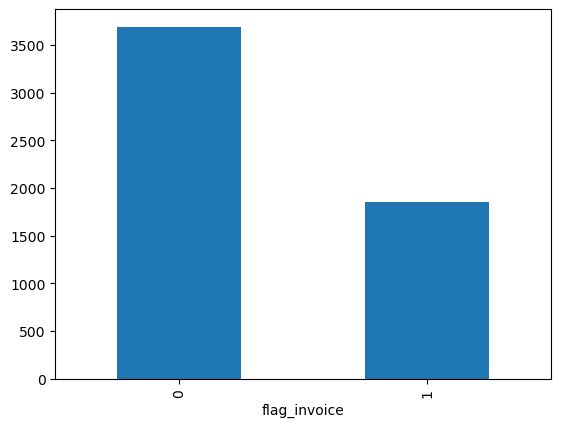

In [64]:
df["flag_invoice"].value_counts().plot(kind='bar')

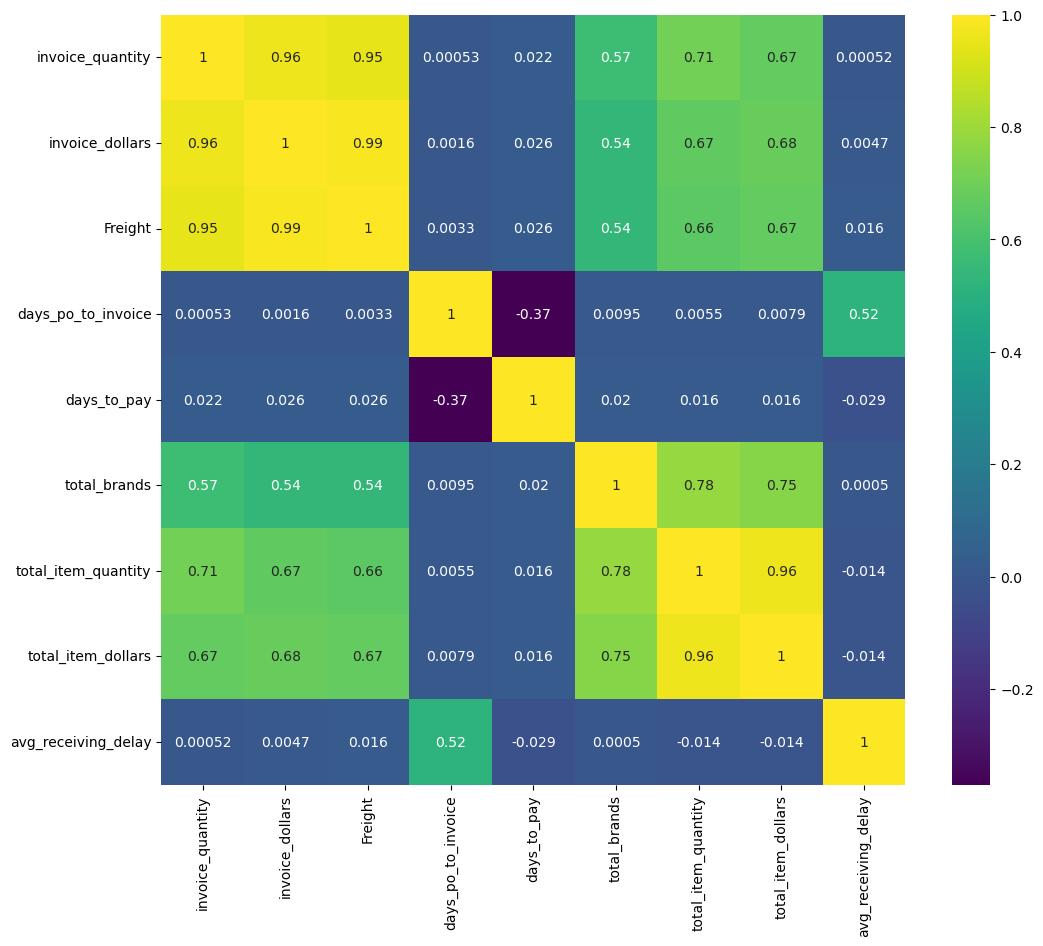

In [65]:
plt.figure(figsize=(12,10))

sns.heatmap(df.iloc[:, 1:-1].select_dtypes(['number']).corr(), cmap="viridis", annot=True)
plt.show()

## Running T-Test to select the features that are important 

In [68]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [73]:
significant_features = []
non_significant_features = []
result = []

In [74]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice',
          'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [81]:
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    print(f"\n{metric}:")
    print(f"  Flagged: {flagged_mean:.2f} | Normal: {normal_mean:.2f} | p={p_value:.4f} | {'SIGNIFICANT' if p_value < 0.05 else 'Not Sig.'}")
    
    if p_value < 0.05:
        significant_features.append(metric)
        result.append({
            'metric': metric,
            'flagged_mean': flagged_mean.round(2),
            'normal_mean': normal_mean.round(2),
            'p_value': p_value.round(2)
        })
    else:
        non_significant_features.append(metric)


invoice_quantity:
  Flagged: 6728.28 | Normal: 5723.55 | p=0.0213 | SIGNIFICANT

invoice_dollars:
  Flagged: 65600.61 | Normal: 54302.64 | p=0.0080 | SIGNIFICANT

Freight:
  Flagged: 334.02 | Normal: 276.89 | p=0.0082 | SIGNIFICANT

days_po_to_invoice:
  Flagged: 17.23 | Normal: 16.02 | p=0.0000 | SIGNIFICANT

days_to_pay:
  Flagged: 35.42 | Normal: 35.49 | p=0.6924 | Not Sig.

total_brands:
  Flagged: 42.29 | Normal: 40.82 | p=0.5077 | Not Sig.

total_item_quantity:
  Flagged: 6728.28 | Normal: 5723.55 | p=0.0213 | SIGNIFICANT

total_item_dollars:
  Flagged: 65600.61 | Normal: 54302.64 | p=0.0080 | SIGNIFICANT

avg_receiving_delay:
  Flagged: 8.47 | Normal: 7.27 | p=0.0000 | SIGNIFICANT


In [76]:
non_significant_features

['days_to_pay', 'total_brands']

In [174]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice', 'total_item_dollars']]
Y = df["flag_invoice"]

In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [176]:
X.describe().round()

# We are seeing very high max quantity and total_item_dollars and other in features, hence this would require scaling

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [177]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [179]:
model1 = LogisticRegression(random_state=101)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=101)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=101)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=101)

In [180]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [181]:
def evaluate_metric(model, X_test_scaled, y_test, model_name):
    y_pred = model.predict(X_test_scaled)
    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"Classification Report: \n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")

In [182]:
evaluate_metric(model1, X_test_scaled, y_test, "Logictic Regression")
evaluate_metric(model2, X_test_scaled, y_test, "Decision Tree Classifier")
evaluate_metric(model3, X_test_scaled, y_test, "Random Forest Classifier")


Logictic Regression
Accuracy: 0.69
Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.98      0.81       757
           1       0.61      0.06      0.10       352

    accuracy                           0.69      1109
   macro avg       0.65      0.52      0.46      1109
weighted avg       0.66      0.69      0.59      1109

Confusion Matrix: 
[[744  13]
 [332  20]]

Decision Tree Classifier
Accuracy: 0.81
Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       757
           1       0.69      0.73      0.71       352

    accuracy                           0.81      1109
   macro avg       0.78      0.79      0.79      1109
weighted avg       0.82      0.81      0.81      1109

Confusion Matrix: 
[[643 114]
 [ 94 258]]

Random Forest Classifier
Accuracy: 0.89
Classification Report: 
              precision    recall  f1-score   support

           0     

In [183]:
imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

imp

# You will notice the features "total_brands" and "days_po_to_invoice" have least importance, so remove them.

,feature,importance
6,total_item_dollars,0.219133
4,total_item_quantity,0.182609
1,invoice_dollars,0.154105
0,invoice_quantity,0.145504
2,Freight,0.139305
3,total_brands,0.087232
5,days_po_to_invoice,0.072112


In [184]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
Y = df["flag_invoice"]

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [186]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [187]:
model1 = LogisticRegression(random_state=101)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=101)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=101)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=101)

In [188]:
evaluate_metric(model1, X_test_scaled, y_test, "Logictic Regression")
evaluate_metric(model2, X_test_scaled, y_test, "Decision Tree Classifier")
evaluate_metric(model3, X_test_scaled, y_test, "Random Forest Classifier")


Logictic Regression
Accuracy: 0.68
Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.99      0.81       757
           1       0.00      0.00      0.00       352

    accuracy                           0.68      1109
   macro avg       0.34      0.50      0.40      1109
weighted avg       0.46      0.68      0.55      1109

Confusion Matrix: 
[[752   5]
 [352   0]]

Decision Tree Classifier
Accuracy: 0.82
Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       757
           1       0.71      0.74      0.72       352

    accuracy                           0.82      1109
   macro avg       0.79      0.80      0.79      1109
weighted avg       0.82      0.82      0.82      1109

Confusion Matrix: 
[[650 107]
 [ 93 259]]

Random Forest Classifier
Accuracy: 0.89
Classification Report: 
              precision    recall  f1-score   support

           0     

## Hyperparamter Tuning

In [189]:
param_grid = {
    "n_estimators": [100,200,300],
    "max_depth" : [None, 4,5,6],
    "min_samples_split": [2,3,5],
    "min_samples_leaf": [1,2,5],
    "criterion": ["gini", "entropy"]
}

In [190]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=101,
    n_jobs=-1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_metric(grid_search, X_test_scaled, y_test, "Hypertuned Random Forest")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Hypertuned Random Forest
Accuracy: 0.89
Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       757
           1       0.93      0.71      0.81       352

    accuracy                           0.89      1109
   macro avg       0.90      0.84      0.87      1109
weighted avg       0.90      0.89      0.89      1109

Confusion Matrix: 
[[738  19]
 [101 251]]


In [191]:
print(grid_search.best_params_)

{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
